MERFISH to MERFISH Alignment (Affine Only)
=========================================

This is a Squidpy-side notebook written as a close copy of the upstream STalign affine-only MERFISH notebook, using the same real MERFISH CSVs from `tmp/STalign_upstream/docs/merfish_data/`.

Unlike the earlier lightweight examples, this notebook does not downsample the data.

In [3]:
from __future__ import annotations

%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import squidpy as sq
from squidpy.experimental.tl._stalign_core import _grid_points, _interp, _transform_grid_backward


def _find_repo_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists() and (path / "src" / "squidpy").exists():
            return path
    raise FileNotFoundError("Could not locate the squidpy repo root from the current working directory.")


def _extent_from_grid(grid: tuple[np.ndarray, np.ndarray]) -> tuple[float, float, float, float]:
    y, x = grid
    dy = y[1] - y[0]
    dx = x[1] - x[0]
    return (x[0] - dx / 2.0, x[-1] + dx / 2.0, y[-1] + dy / 2.0, y[0] - dy / 2.0)


REPO_ROOT = _find_repo_root(Path.cwd().resolve())
DATA_DIR = REPO_ROOT / "tmp" / "stalign_merfish_data"
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Expected STalign tutorial data under: {DATA_DIR}")

Load the same real MERFISH files used by the upstream STalign notebook.

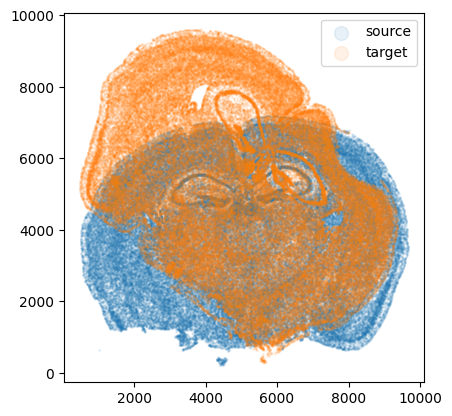

In [4]:
fname_src = DATA_DIR / "datasets_mouse_brain_map_BrainReceptorShowcase_Slice2_Replicate3_cell_metadata_S2R3.csv.gz"
fname_tgt = DATA_DIR / "datasets_mouse_brain_map_BrainReceptorShowcase_Slice2_Replicate2_cell_metadata_S2R2.csv.gz"

df_src = pd.read_csv(fname_src)
df_tgt = pd.read_csv(fname_tgt)

xI = np.array(df_src["center_x"])
yI = np.array(df_src["center_y"])

xJ = np.array(df_tgt["center_x"])
yJ = np.array(df_tgt["center_y"])

fig, ax = plt.subplots()
ax.scatter(xI, yI, s=1, alpha=0.1, label="source")
ax.scatter(xJ, yJ, s=1, alpha=0.1, label="target")
ax.legend(markerscale=10)
ax.set_aspect("equal")

Match the upstream notebook's manual affine initialization.

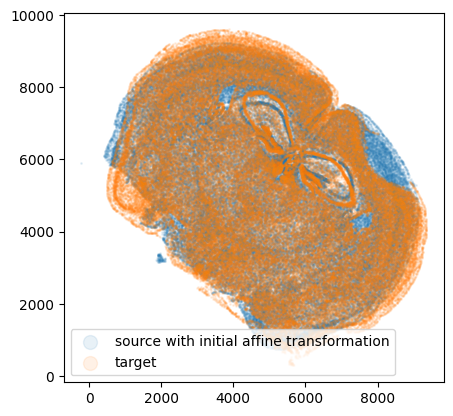

In [5]:
theta_deg = 45
theta0 = (np.pi / 180.0) * -theta_deg

L = np.array(
    [
        [np.cos(theta0), -np.sin(theta0)],
        [np.sin(theta0), np.cos(theta0)],
    ]
)

source_L = np.matmul(L, np.array([xI, yI]))
xI_L = source_L[0]
yI_L = source_L[1]

T = np.array(
    [
        np.mean(xI) - np.cos(theta0) * np.mean(xI) + np.sin(theta0) * np.mean(yI) - (np.mean(xI) - np.mean(xJ)),
        np.mean(yI) - np.sin(theta0) * np.mean(xI) - np.cos(theta0) * np.mean(yI) - (np.mean(yI) - np.mean(yJ)),
    ]
)

xI_L_T = xI_L + T[0]
yI_L_T = yI_L + T[1]

fig, ax = plt.subplots()
ax.scatter(xI_L_T, yI_L_T, s=1, alpha=0.1, label="source with initial affine transformation")
ax.scatter(xJ, yJ, s=1, alpha=0.1, label="target")
ax.legend(markerscale=10)
ax.set_aspect("equal")

Rasterize the point clouds at 30 micron resolution, matching the upstream notebook.

Text(0.5, 1.0, 'Target rasterized')

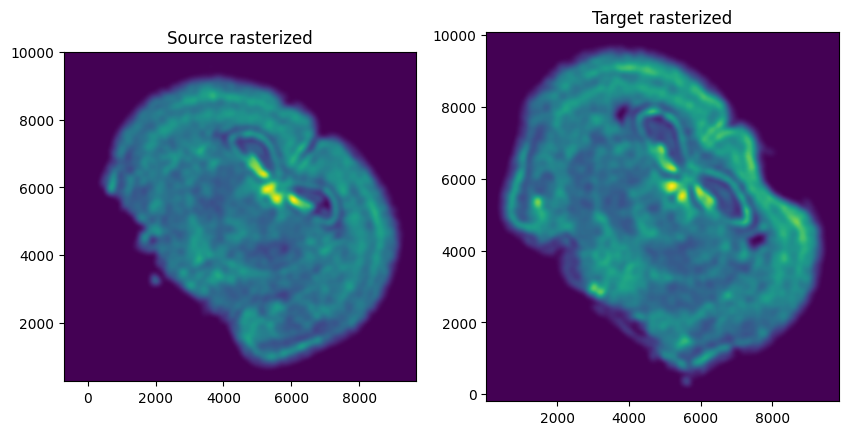

In [6]:
source_row_col = np.stack([yI_L_T, xI_L_T], axis=1)
target_row_col = np.stack([yJ, xJ], axis=1)

preprocess_config = sq.experimental.tl.stalign_tools.STalignPreprocessConfig(
    dx=30.0,
    blur=1.5,
)
prep = sq.experimental.tl.stalign_tools.stalign_preprocess(
    source_row_col,
    target_row_col,
    config=preprocess_config,
)

extentI = _extent_from_grid(prep.source_grid)
extentJ = _extent_from_grid(prep.target_grid)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(prep.source_image[0], extent=extentI)
ax[1].imshow(prep.target_image[0], extent=extentJ)
ax[0].invert_yaxis()
ax[1].invert_yaxis()
ax[0].set_title("Source rasterized")
ax[1].set_title("Target rasterized")

Run the affine-only Squidpy STalign version.

This follows the upstream affine-only notebook idea by preventing diffeomorphic updates.

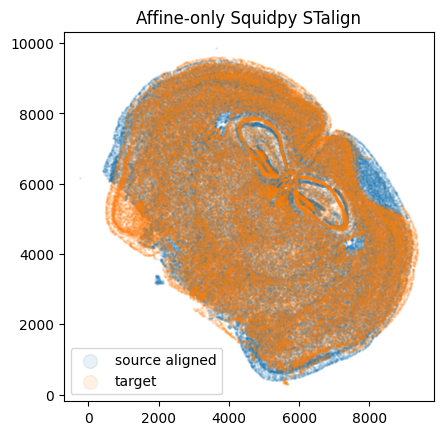

In [7]:
config = sq.experimental.tl.stalign_tools.STalignConfig(
    preprocess=preprocess_config,
    registration=sq.experimental.tl.stalign_tools.STalignRegistrationConfig(
        niter=1000,
        diffeo_start=1001,
        epV=50.0,
        a=500.0,
        expand=1.0,
        nt=1,
    ),
)

affine_only = sq.experimental.tl.stalign_tools.stalign_points(
    source_row_col,
    target_row_col,
    config=config,
)

affine_only_xy = np.asarray(affine_only.aligned_points)[:, [1, 0]]

fig, ax = plt.subplots()
ax.scatter(affine_only_xy[:, 0], affine_only_xy[:, 1], s=1, alpha=0.1, label="source aligned")
ax.scatter(xJ, yJ, s=1, alpha=0.1, label="target")
ax.legend(markerscale=10)
ax.set_title("Affine-only Squidpy STalign")
ax.set_aspect("equal")

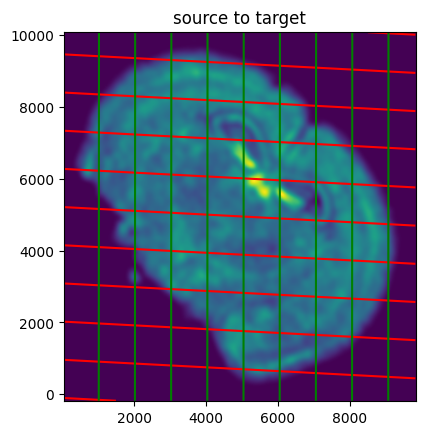

In [8]:
phii = _transform_grid_backward(prep.target_grid, affine_only.velocity_grid, affine_only.velocity, affine_only.affine)
phiI = _interp(prep.source_grid, prep.source_image, phii, mode="nearest")

fig, ax = plt.subplots()
levels = np.arange(-100000, 100000, 1000)
ax.contour(prep.target_grid[1], prep.target_grid[0], np.asarray(phii[0]), colors="r", linestyles="-", levels=levels)
ax.contour(prep.target_grid[1], prep.target_grid[0], np.asarray(phii[1]), colors="g", linestyles="-", levels=levels)
ax.set_aspect("equal")
ax.set_title("source to target")
ax.imshow(np.moveaxis(np.asarray(phiI), 0, -1), extent=extentJ)
ax.invert_yaxis()

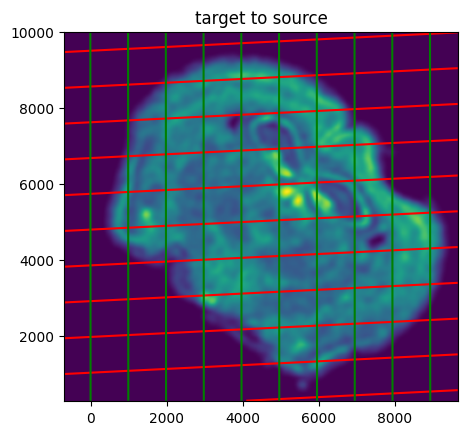

In [9]:
source_grid = _grid_points(tuple(np.asarray(v) for v in prep.source_grid))
source_grid_points = np.stack([np.asarray(source_grid[0]).ravel(), np.asarray(source_grid[1]).ravel()], axis=1)
phi_points = np.asarray(affine_only.transform_points(source_grid_points, direction="forward", point_order="row_col"))
phi = np.stack(
    [
        phi_points[:, 0].reshape(np.asarray(source_grid[0]).shape),
        phi_points[:, 1].reshape(np.asarray(source_grid[1]).shape),
    ]
)
phiiJ = _interp(prep.target_grid, prep.target_image, phi, mode="nearest")

fig, ax = plt.subplots()
levels = np.arange(-100000, 100000, 1000)
ax.contour(prep.source_grid[1], prep.source_grid[0], phi[0], colors="r", linestyles="-", levels=levels)
ax.contour(prep.source_grid[1], prep.source_grid[0], phi[1], colors="g", linestyles="-", levels=levels)
ax.set_aspect("equal")
ax.set_title("target to source")
ax.imshow(np.moveaxis(np.asarray(phiiJ), 0, -1), extent=extentI)
ax.invert_yaxis()

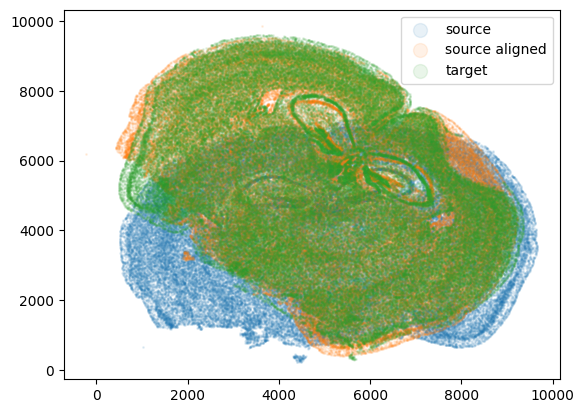

In [10]:
xI_LDDMM = affine_only_xy[:, 0]
yI_LDDMM = affine_only_xy[:, 1]

fig, ax = plt.subplots()
ax.scatter(xI, yI, s=1, alpha=0.1, label="source")
ax.scatter(xI_LDDMM, yI_LDDMM, s=1, alpha=0.1, label="source aligned")
ax.scatter(xJ, yJ, s=1, alpha=0.1, label="target")
ax.legend(markerscale=10)

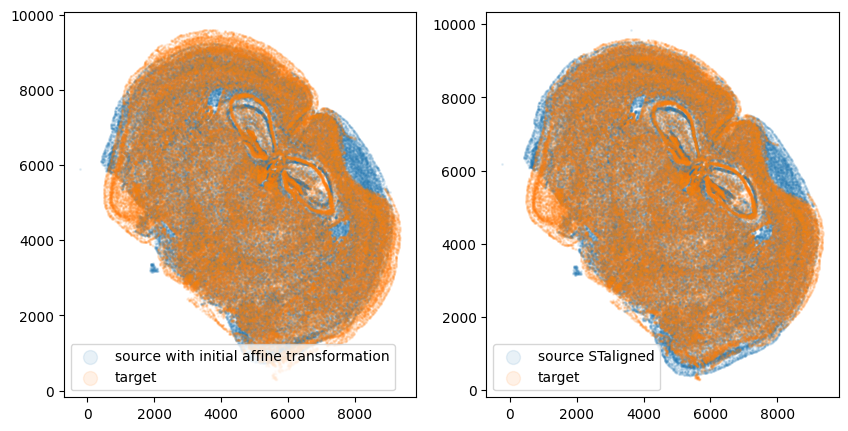

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(xI_L_T, yI_L_T, s=1, alpha=0.1, label="source with initial affine transformation")
ax[0].scatter(xJ, yJ, s=1, alpha=0.1, label="target")
ax[1].scatter(xI_LDDMM, yI_LDDMM, s=1, alpha=0.1, label="source STaligned")
ax[1].scatter(xJ, yJ, s=1, alpha=0.1, label="target")
ax[0].legend(markerscale=10, loc="lower left")
ax[1].legend(markerscale=10, loc="lower left")

In [12]:
results_affine_only = df_src.copy()
results_affine_only["aligned_x"] = affine_only_xy[:, 0]
results_affine_only["aligned_y"] = affine_only_xy[:, 1]
results_affine_only.head()

,Unnamed: 0,fov,volume,center_x,center_y,min_x,max_x,min_y,max_y,aligned_x,aligned_y
0,158338042824236264719696604356349910479,33,532.778772,617.916619,2666.520010,614.725219,621.108019,2657.545209,2675.494810,930.580872,7940.090820
1,260594727341160372355976405428092853003,33,1004.430016,596.808018,2763.450012,589.669218,603.946818,2757.013212,2769.886812,984.650574,8025.963379
2,307643940700812339199503248604719950662,33,1267.183208,578.880018,2748.978012,570.877217,586.882818,2740.489211,2757.466812,961.570312,8029.776367
3,30863303465976316429997331474071348973,33,1403.401822,572.616017,2766.690012,564.937217,580.294818,2756.581212,2776.798812,969.736877,8047.367188
4,313162718584097621688679244357302162401,33,507.949497,608.364018,2687.418010,603.061218,613.666818,2682.493210,2692.342810,938.677368,7962.551758


In [13]:
out_path = (
    REPO_ROOT
    / "tmp"
    / "mouse_brain_map_BrainReceptorShowcase_Slice2_Replicate3_STalign_to_Slice2_Replicate2_affine_only_squidpy.csv.gz"
)
results_affine_only.to_csv(out_path, compression="gzip", index=False)
out_path

PosixPath('/Users/selman/projects/squidpy/tmp/mouse_brain_map_BrainReceptorShowcase_Slice2_Replicate3_STalign_to_Slice2_Replicate2_affine_only_squidpy.csv.gz')

Reference: `tmp/STalign_upstream/docs/notebooks/merfish-merfish-alignment-affine-only.ipynb`